In [30]:
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv
load_dotenv()
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [31]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [32]:
class BatsmanState(TypedDict):
    runs: int 
    balls: int
    fours: int
    sixs: int
    
    strikeRate: float
    ballsPerBoundry: float
    boundaryPercentage: float

In [33]:
def calculateStrikeRate(state: BatsmanState):
    strikeRate = (state['runs']/state['balls'])*100
    state['strikeRate'] = strikeRate
    return {"strikeRate" : strikeRate}

In [34]:
def calculateBallsPerBoundary(state: BatsmanState):
    ballsPerBoundary = state['balls']/(state["fours"]+state['sixs'])
    state['ballsPerBoundry'] = ballsPerBoundary
    return {"ballsPerBoundry" : ballsPerBoundary}

In [35]:
def calculateBoundaryPercentage(state: BatsmanState):
    boundaryPercentage = ((state["fours"]*4+state['sixs']*6)*100)/state['balls']
    state['boundaryPercentage'] = boundaryPercentage
    return {"boundaryPercentage" : boundaryPercentage}

In [36]:
def summary(state: BatsmanState):

    summary = f"""
Strike Rate - {state['strikeRate']} \n
Balls per boundary - {state['ballsPerBoundry']} \n
Boundary percent - {state['boundaryPercentage']}
"""
    
    return {'summary': summary}

In [39]:
graph = StateGraph(BatsmanState)

graph.add_node(calculateStrikeRate)
graph.add_node(calculateBallsPerBoundary)
graph.add_node(calculateBoundaryPercentage)    
graph.add_node(summary)

graph.add_edge(START , "calculateStrikeRate")
graph.add_edge(START , "calculateBallsPerBoundary")
graph.add_edge(START , "calculateBoundaryPercentage")

graph.add_edge("calculateStrikeRate" , "summary")
graph.add_edge("calculateBallsPerBoundary" , "summary")
graph.add_edge("calculateBoundaryPercentage" , "summary")

graph.add_edge("summary" , END)
    

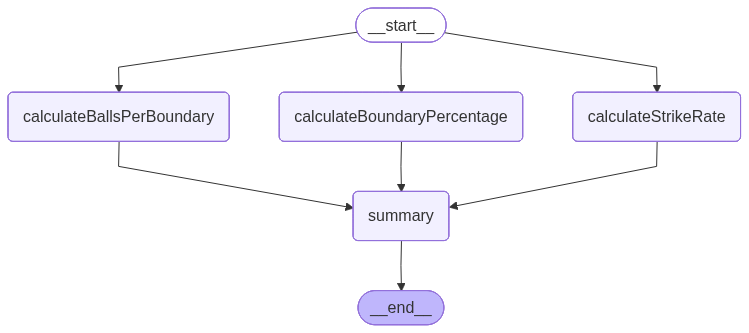

In [40]:
graph.compile()

In [41]:
workFlow = graph.compile()

In [44]:
initialState = {"balls" : 100 , "runs" : 180 , "sixs" : 9 , "fours" : 15}

finalState = workFlow.invoke(initialState)

In [45]:
finalState


{'runs': 180,
 'balls': 100,
 'fours': 15,
 'sixs': 9,
 'strikeRate': 180.0,
 'ballsPerBoundry': 4.166666666666667,
 'boundaryPercentage': 114.0}